In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [28]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep Learning exp/DL EXP-1spreadsheet - Sheet1 (2).csv')
X = dataset1[['INPUT']].values
y = dataset1[['OUTPUT']].values

In [29]:
dataset1.head()

,INPUT,OUTPUT
0,NaN,NaN
1,6.0,56.0
2,53.0,96.0
3,8.0,25.0
4,11.0,41.0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [31]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [51]:
# Name: ARCHANA T
# Register Number: 212223240013
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss': []}
  def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x

In [52]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(lig.parameters(),lr=0.001)

In [53]:
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs):
        optimizer. zero_grad()
        loss=criterion(ai_brain(X_train), y_train)
        loss. backward()
        optimizer.step()
        lig .history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [54]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 3247.521729
Epoch [200/2000], Loss: 2698.449951
Epoch [400/2000], Loss: 1688.102661
Epoch [600/2000], Loss: 767.033264
Epoch [800/2000], Loss: 404.492706
Epoch [1000/2000], Loss: 368.783783
Epoch [1200/2000], Loss: 350.249420
Epoch [1400/2000], Loss: 337.193817
Epoch [1600/2000], Loss: 330.649506
Epoch [1800/2000], Loss: 329.060699


In [55]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: nan


In [56]:
loss_df = pd.DataFrame(lig.history)

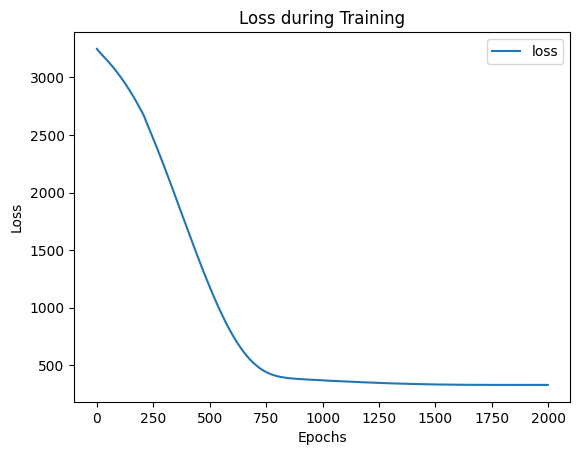

In [57]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [58]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 50.91828918457031
